**Table of contents**<a id='toc0_'></a>    
- [ON/OFF periods (analytical) vs. ON/OFF states (photophysical)](#toc1_)    
  - [Scenario 1: multiple fluorophores](#toc1_1_)    
  - [Scenario 2: single fluorophore](#toc1_2_)    
  - [Figure](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[ON/OFF periods (analytical) vs. ON/OFF states (photophysical)](#toc0_)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fluorophores as fl
import fluopy.routines as rt
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

reading_from = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_2_single_f_statistics"
)
saving_at = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_17_on_off_periods"

## <a id='toc1_1_'></a>[Scenario 1: multiple fluorophores](#toc0_)

In [2]:
fluorophores = fl.construct_fluorophores(name="cy5_dna", count=3, distance=3)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(**rt.PARAMS_DSTORM)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

In [3]:
rng = np.random.default_rng(seed=42)

simulation = si.Simulation(transition_set)
simulation.run(size=1e7, seed=rng)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.36e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


In [4]:
rng = np.random.default_rng(seed=42)
emis = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis.extract(simulation)
rt.emission_post_processing(emis=emis, seed=rng)
blink = bl.Blinking(emis)

In [5]:
on_off_times_photophys_multi_1, on_off_values_photophys_multi_1 = bl.get_off_statistics(
    simulation, index=0
)
on_off_times_photophys_multi_2, on_off_values_photophys_multi_2 = bl.get_off_statistics(
    simulation, index=1
)
on_off_times_photophys_multi_3, on_off_values_photophys_multi_3 = bl.get_off_statistics(
    simulation, index=2
)
on_off_times_analytic_multi, on_off_values_analytic_multi = (
    bl.get_analytical_off_statistics(
        off_frames=blink.off_periods_frames,
        off_periods=blink.off_periods,
        on_frames=blink.on_periods_frames,
        frame_time=blink.emissions.parameters["frame_time"],
    )
)

## <a id='toc1_2_'></a>[Scenario 2: single fluorophore](#toc0_)

In [6]:
fluorophores = fl.construct_fluorophores(name="cy5_dna", count=1)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    **rt.PARAMS_DSTORM,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()


simulation = si.Simulation(transition_set)
simulation.state_series = np.load(reading_from + r"\state_series.npy")
simulation.time_series = np.load(reading_from + r"\time_series.npy")
simulation.transition_series = np.load(reading_from + r"\transition_series.npy")

In [7]:
rng = np.random.default_rng(1)
emis = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis.extract(simulation)
rt.emission_post_processing(emis=emis, seed=rng)

blink = bl.Blinking(emis)
blink_2 = bl.Blinking(emis, memory=3)

In [8]:
on_off_times_photophys, on_off_values_photophys = bl.get_off_statistics(
    simulation, index=0
)
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blink.off_periods_frames,
    off_periods=blink.off_periods,
    on_frames=blink.on_periods_frames,
    frame_time=blink.emissions.parameters["frame_time"],
)

In [9]:
# find a good example, where off times are small
index = np.where(blink.off_periods == 2)[0][
    0
]  # first occurrence of a 2-frame off period
time = blink.off_periods_frames[index]
print(f"short off period starts at time: {time}")

short off period starts at time: 39052


In [10]:
# what is happening around this time?
mask = (simulation.time_series > 39.052) & (simulation.time_series < 39.054)
first_true_index = np.where(mask)[0][0]
last_false_index = first_true_index - 1
first_time_point = simulation.time_series[first_true_index]
previous_time_point = simulation.time_series[last_false_index]
print(
    f"first time point in mask: {first_time_point}"
    f", previous time point: {previous_time_point}"
)
state = simulation.state_series[0][last_false_index]
print(f"state during short off period: {state}")

first time point in mask: 39.053307365278144, previous time point: 39.05034127682117
state during short off period: 9


## <a id='toc1_3_'></a>[Figure](#toc0_)

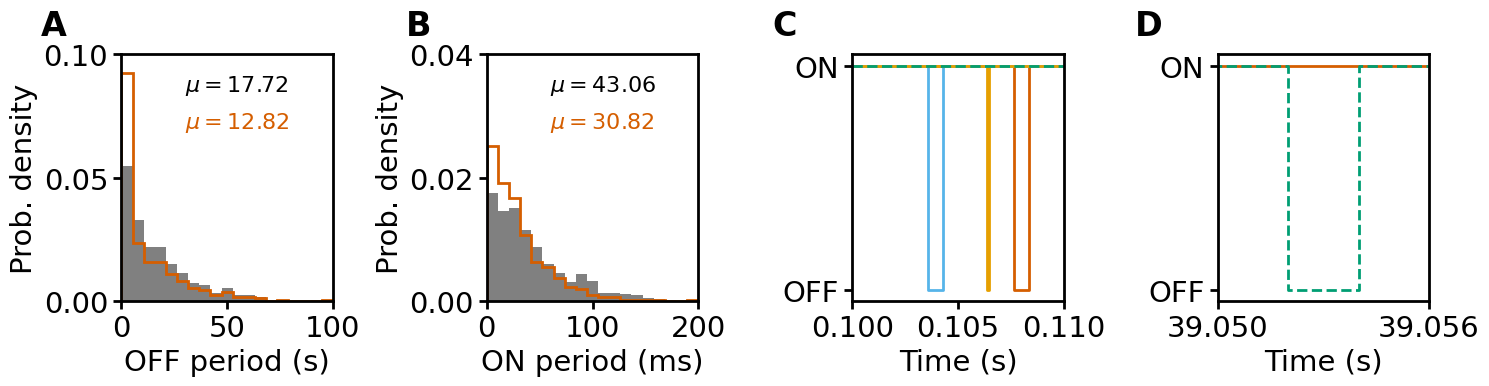

: 

In [ ]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(1, 4)
fig = plt.figure(figsize=(15, 4))
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"

ax = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 100, 20)
blink_2.plot(
    mode="off_histogram",
    axes=ax,
    as_time="s",
    ylim=[0, 0.1],
    xlim=[0, 100],
    color="grey",
    bins=bins,
)
blink.plot(
    mode="off_histogram",
    axes=ax,
    histtype="step",
    lw=2,
    as_time="s",
    ylim=[0, 0.1],
    xlim=[0, 100],
    color=red,
    bins=bins,
    display_mean=False,
    yticks=[0, 0.05, 0.1],
)
ax.text(
    x=0.3, y=0.7, s=rf"$\mu = {12.82}$", transform=ax.transAxes, fontsize=16, color=red
)
ax = fig.add_subplot(gs[0, 1])
bins = np.linspace(0, 200, 20)
blink_2.plot(
    mode="on_histogram",
    axes=ax,
    as_time="ms",
    ylim=[0, 0.04],
    xlim=[0, 200],
    color="grey",
    bins=bins,
)
blink.plot(
    mode="on_histogram",
    axes=ax,
    histtype="step",
    lw=2,
    as_time="ms",
    ylim=[0, 0.04],
    xlim=[0, 200],
    yticks=[0, 0.02, 0.04],
    color=red,
    bins=bins,
    display_mean=False,
)
ax.text(
    x=0.3, y=0.7, s=rf"$\mu = {30.82}$", transform=ax.transAxes, fontsize=16, color=red
)
ax = fig.add_subplot(gs[0, 2])
bl.plot_off_statistics(
    on_off_times_photophys_multi_1,
    on_off_values_photophys_multi_1,
    xlim=[0.1, 0.11],
    color=red,
    axes=ax,
    lw=2,
)
bl.plot_off_statistics(
    on_off_times_photophys_multi_2,
    on_off_values_photophys_multi_2,
    axes=ax,
    color=sky_blue,
    lw=2,
)
bl.plot_off_statistics(
    on_off_times_photophys_multi_3,
    on_off_values_photophys_multi_3,
    axes=ax,
    color=orange,
    fontsize=21,
    lw=2,
)
# plot a horizotnal line
ax.hlines(
    y=1,
    xmin=0.1,
    xmax=0.11,
    color=green,
    ls="--",
    lw=2,
)

ax = fig.add_subplot(gs[0, 3])

bl.plot_off_statistics(
    on_off_times_photophys,
    on_off_values_photophys,
    axes=ax,
    color=red,
    lw=2,
)
bl.plot_off_statistics(
    on_off_times_analytic,
    on_off_values_analytic,
    xlim=[39050 * 0.001, 39056 * 0.001],
    color=green,
    axes=ax,
    ls="--",
    xticks=[39.05, 39.056],
    fontsize=21,
    lw=2,
)

axes = fig.get_axes()
for axis, letter in zip(axes, ["A", "B", "C", "D"]):
    offset = -0.26
    axis.text(
        offset,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()

fig.savefig(
    saving_at + r"\on_off_periods.png",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=300,
)